In [7]:
# [Requirement 4: Data loading]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Visualization settings
%matplotlib inline
sns.set_style("whitegrid")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# 1. Load Data
file_path = '/content/drive/My Drive/Academics/AI ML/Assignment/Assignment 2/diabetes.csv'
# For demonstration, I will load a built-in dataset.
# UNCOMMENT the line above and COMMENT OUT the lines below to use your file.
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# 2. [Requirement 2: Handle Missing Values]
imputer = SimpleImputer(strategy='mean')
# Assuming 'df' contains your features. If you have categorical cols, handle them separately.
# This example assumes mostly numeric data for SVM efficiency.

# 3. [Requirement 2: Encode Categorical Features]
# If your target is text (e.g., "Yes"/"No"), encode it:
# le = LabelEncoder()
# df['target_col'] = le.fit_transform(df['target_col'])

# Define X (features) and y (target)
X = df.drop('target', axis=1) # Replace 'target' with your actual target column name
y = df['target']

# 4. [Requirement 2: Split into train/test]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. [Requirement 2: Normalize/Standardize]
# SVM requires scaling because it calculates distances.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Complete.")

Data Preprocessing Complete.


In [9]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# [Requirement 1 & 4: Hyperparameter Tuning]
# We set up a grid of parameters to test
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf', 'poly', 'sigmoid'],
    'degree': [2, 3] # Only used by 'poly' kernel
}

grid = GridSearchCV(SVC(probability=True), param_grid, refit=True, verbose=2, cv=3)

# Train the model
print("Starting training (this may take a moment)...")
grid.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid.best_params_}")
best_model = grid.best_estimator_

Starting training (this may take a moment)...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.1s
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.3s
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.2s
[CV] END ..............C=0.1, degree=2, gamma=1, kernel=poly; total time=   0.2s
[CV] END ..............C=0.1, degree=2, gamma=1, kernel=poly; total time=   0.2s
[CV] END ..............C=0.1, degree=2, gamma=1, kernel=poly; total time=   0.2s
[CV] END ...........C=0.1, degree=2, gamma=1, kernel=sigmoid; total time=   0.1s
[CV] END ...........C=0.1, degree=2, gamma=1, kernel=sigmoid; total time=   0.1s
[CV] END ...........C=0.1, degree=2, gamma=1, kernel=sigmoid; total time=   0.1s
[CV] END .............C=0.1, degree=2, gamma=0.1, kernel=rbf; total time=   0.1s
[CV] END .............C=0.1, degree=2, gamma=0.1, kernel=rbf; total time=   0.1s
[

Accuracy: 0.9824561403508771

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

AUC Score: 0.9970520799213888


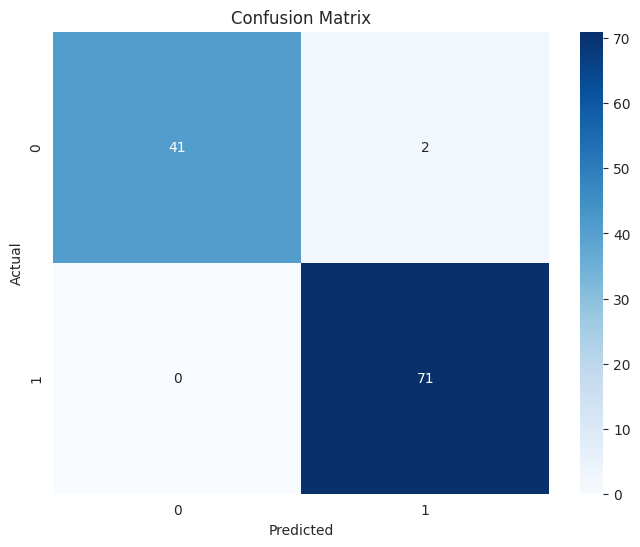

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Predictions
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# [Requirement 5: Evaluation Metrics]
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_proba))

# [Requirement 5: Confusion Matrix Heatmap]
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

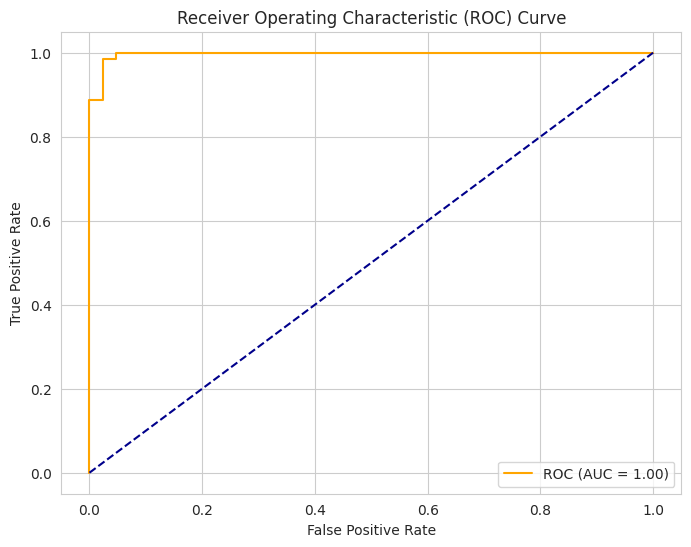

In [11]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label=f'ROC (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

Sample Predictions (First 10):
     Actual  Predicted      Prob
204       1          1  0.924768
70        0          0  0.000071
131       0          0  0.001903
431       1          1  0.999999
540       1          1  1.000000
567       0          0  0.000058
369       0          0  0.000010
29        0          0  0.108768
81        1          1  0.720961
477       1          1  0.997413


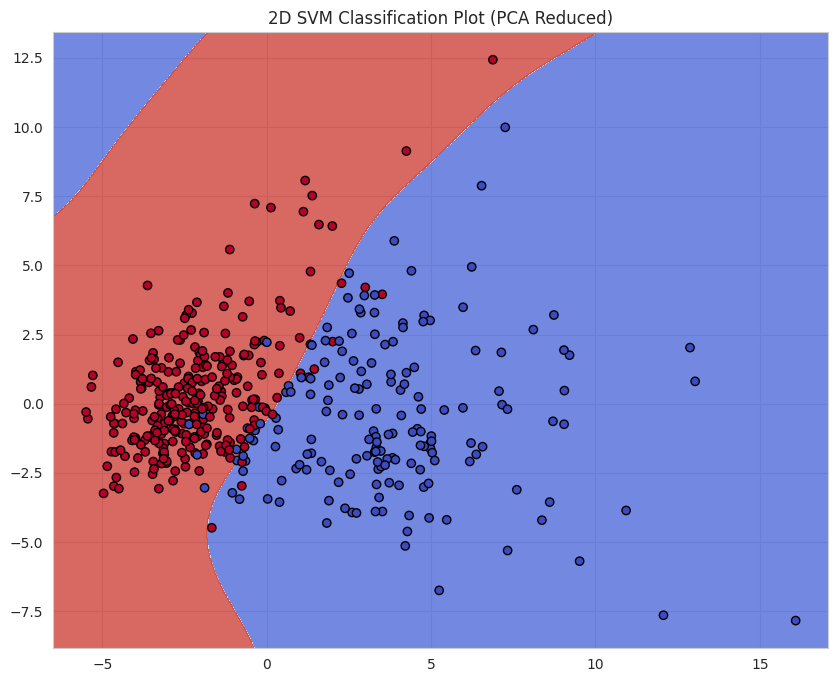

In [12]:
# 1. Sample Predictions Table
samples = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Prob': y_proba})
print("Sample Predictions (First 10):")
print(samples.head(10))

# 2. [Requirement 5: 2D Classification Plot]
from sklearn.decomposition import PCA

# Reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Retrain a simple model on just 2 dims for the plot
model_2d = SVC(kernel=grid.best_params_['kernel'], C=grid.best_params_['C'], probability=True)
model_2d.fit(X_train_pca, y_train)

# Create a mesh to plot in
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', cmap='coolwarm')
plt.title('2D SVM Classification Plot (PCA Reduced)')
plt.show()